# Proyecto Final — Conditional Imitation Learning (CIL)
## MR4010.10 Navegacion Autonoma — Maestria en IA, Tec de Monterrey

Este notebook entrena un modelo de **Conditional Imitation Learning (CIL)** para conducir un vehiculo autonomo en Webots. La idea, de **Codevilla et al. (2018)**, es que una sola red aprenda a conducir **condicionada a un comando de navegacion** (seguir / izquierda / recto / derecha), de modo que el mismo modelo tome rutas distintas en una interseccion segun el comando.

**Flujo del notebook (con visualizaciones en cada etapa):**
1. Entorno y GPU
2. Clonar el dataset y el codigo
3. Cargar el dataset
4. Analisis exploratorio (balance, distribucion de angulos, muestras)
5. Preprocesamiento (antes / despues)
6. Data augmentation (flip que niega el angulo e intercambia LEFT<->RIGHT, brillo)
7. Arquitectura del modelo (resumen + diagrama)
8. Entrenamiento
9. Curvas de entrenamiento
10. Evaluacion (MAE por comando, dispersion, errores, predicciones visualizadas)
11. Exportacion a TensorFlow Lite
12. Integracion en Webots

> La velocidad **no** forma parte del entrenamiento (la tarea lo indica): solo se entrena el angulo de direccion.

## 1. Entorno y GPU
Verificamos la version de TensorFlow y si Colab nos asigno una GPU (acelera mucho el entrenamiento).

In [1]:
import tensorflow as tf
print('TensorFlow', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU disponible:', gpus if gpus else 'NO (usara CPU, sera mas lento)')

TensorFlow 2.21.0
GPU disponible: NO (usara CPU, sera mas lento)


## 2. Clonar el dataset y el codigo

El **dataset crudo** (imagenes + `driving_log.csv`) vive en un repo de GitHub; el **codigo** de entrenamiento (`train_cil.py`) en el repo del proyecto. Ajusta las URLs si cambian los nombres.

In [2]:
import os, sys

if os.path.isdir('/content'):
    # --- En Google Colab: clonar el dataset y el codigo desde GitHub ---
    !git clone -q https://github.com/oscar-ramirez-anaya/cil_dataset
    !git clone -q https://github.com/oscar-ramirez-anaya/navegacion_autonoma_final
    sys.path.append('/content/navegacion_autonoma_final/cil_training')
    DATA_DIR = '/content/cil_dataset'
else:
    # --- Ejecucion local (asi quedan incrustadas las graficas en el notebook) ---
    sys.path.append(os.path.abspath('.'))
    DATA_DIR = os.path.abspath(os.path.join('..', '..', 'cil_dataset'))

print('DATA_DIR =', DATA_DIR)

DATA_DIR = /Users/oscarramirezanaya/Documents/proyectos/maestria/cil_dataset


## 3. Cargar el dataset
Reutilizamos `train_cil.load_dataset`, que aplica **exactamente el mismo preprocesamiento** que usara el controlador en Webots (recorte de la carretera, RGB, resize, normalizacion). Asi la inferencia coincide con el entrenamiento.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2, os, glob, collections
import train_cil as cil

plt.rcParams['figure.dpi'] = 110
CMD_NAMES = cil.CMD_NAMES
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  # FOLLOW, LEFT, STRAIGHT, RIGHT

X, C, y = cil.load_dataset(DATA_DIR)
print(f'\nImagenes: {X.shape}  |  comandos: {C.shape}  |  angulos: {y.shape}')
print(f'Entrada del modelo: {cil.IMG_H} x {cil.IMG_W} x 3  |  rango de angulo: +/-{cil.MAX_ANGLE} rad')

[DATA] Cargadas 13296 imagenes (0 faltantes/ilegibles)
[BALANCE] (crudo) {'FOLLOW': 7242, 'LEFT': 1882, 'STRAIGHT': 3621, 'RIGHT': 551}

Imagenes: (13296, 88, 200, 3)  |  comandos: (13296,)  |  angulos: (13296,)
Entrada del modelo: 88 x 200 x 3  |  rango de angulo: +/-0.5 rad


## 4. Analisis exploratorio del dataset

Antes de entrenar conviene **mirar los datos**. Tres preguntas clave para Behavioral Cloning:
- Hay **muestras de los 4 comandos**? (sin LEFT/STRAIGHT/RIGHT el modelo no aprende a girar por comando)
- Esta **balanceado** entre giros a izquierda y derecha?
- Los **angulos** cubren bien el rango (no todo en cero)?

### 4.1 Balance por comando de navegacion

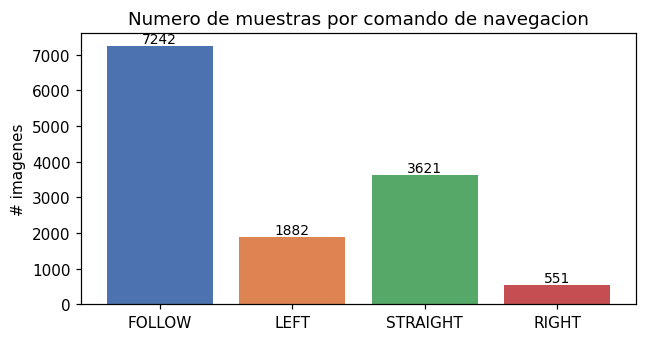

In [4]:
counts = collections.Counter(C.tolist())
vals = [counts.get(i, 0) for i in range(cil.NUM_COMMANDS)]
names = [CMD_NAMES[i] for i in range(cil.NUM_COMMANDS)]

plt.figure(figsize=(6.5, 3.2))
bars = plt.bar(names, vals, color=COLORS)
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v, str(v), ha='center', va='bottom', fontsize=9)
plt.title('Numero de muestras por comando de navegacion')
plt.ylabel('# imagenes')
plt.show()

faltantes = [CMD_NAMES[i] for i in range(cil.NUM_COMMANDS) if vals[i] == 0]
if faltantes:
    print('ADVERTENCIA: no hay muestras de:', faltantes,
          '\n-> Recolecta mas datos presionando 1-4 en las intersecciones del Mundo #1.')

### 4.2 Distribucion del angulo de direccion

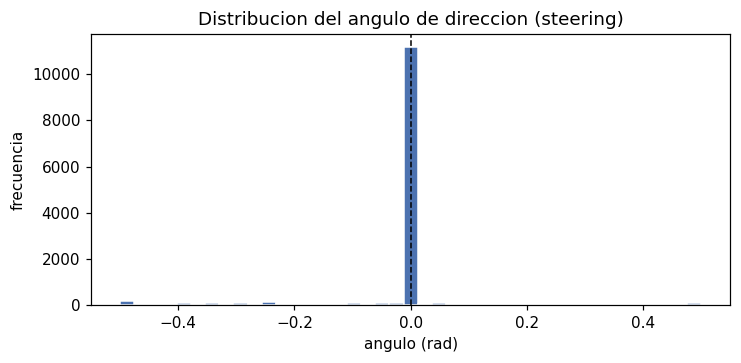

Giros a la izquierda (ang<0): 1440   |   a la derecha (ang>0): 895   |   recto (0): 10961
Idealmente izquierda ~ derecha. El flip horizontal del augmentation ayuda a balancearlo.


In [5]:
plt.figure(figsize=(7.5, 3.2))
plt.hist(y, bins=41, color='#4C72B0', edgecolor='white')
plt.axvline(0, color='k', ls='--', lw=1)
plt.title('Distribucion del angulo de direccion (steering)')
plt.xlabel('angulo (rad)'); plt.ylabel('frecuencia')
plt.show()

izq = int(np.sum(y < -1e-6)); der = int(np.sum(y > 1e-6)); rec = int(np.sum(np.abs(y) <= 1e-6))
print(f'Giros a la izquierda (ang<0): {izq}   |   a la derecha (ang>0): {der}   |   recto (0): {rec}')
print('Idealmente izquierda ~ derecha. El flip horizontal del augmentation ayuda a balancearlo.')

### 4.3 Angulo por comando
Cada comando deberia mostrar el patron esperado: LEFT con angulos negativos, RIGHT positivos, FOLLOW/STRAIGHT cerca de cero.

/var/folders/qj/6h1gvmh96z1d3zqlfjrwh3000000gn/T/ipykernel_11731/4089493271.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d for _, d in data], labels=[n for n, _ in data], showmeans=True)


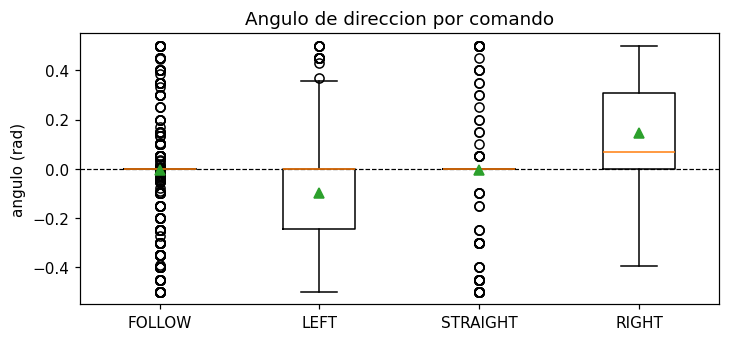

In [6]:
data = [(CMD_NAMES[i], y[C == i]) for i in range(cil.NUM_COMMANDS) if np.any(C == i)]
plt.figure(figsize=(7.5, 3.2))
plt.boxplot([d for _, d in data], labels=[n for n, _ in data], showmeans=True)
plt.axhline(0, color='k', ls='--', lw=0.8)
plt.title('Angulo de direccion por comando')
plt.ylabel('angulo (rad)')
plt.show()

### 4.4 Muestras de imagenes por comando
Una mirada cualitativa: que ve el vehiculo para cada comando.

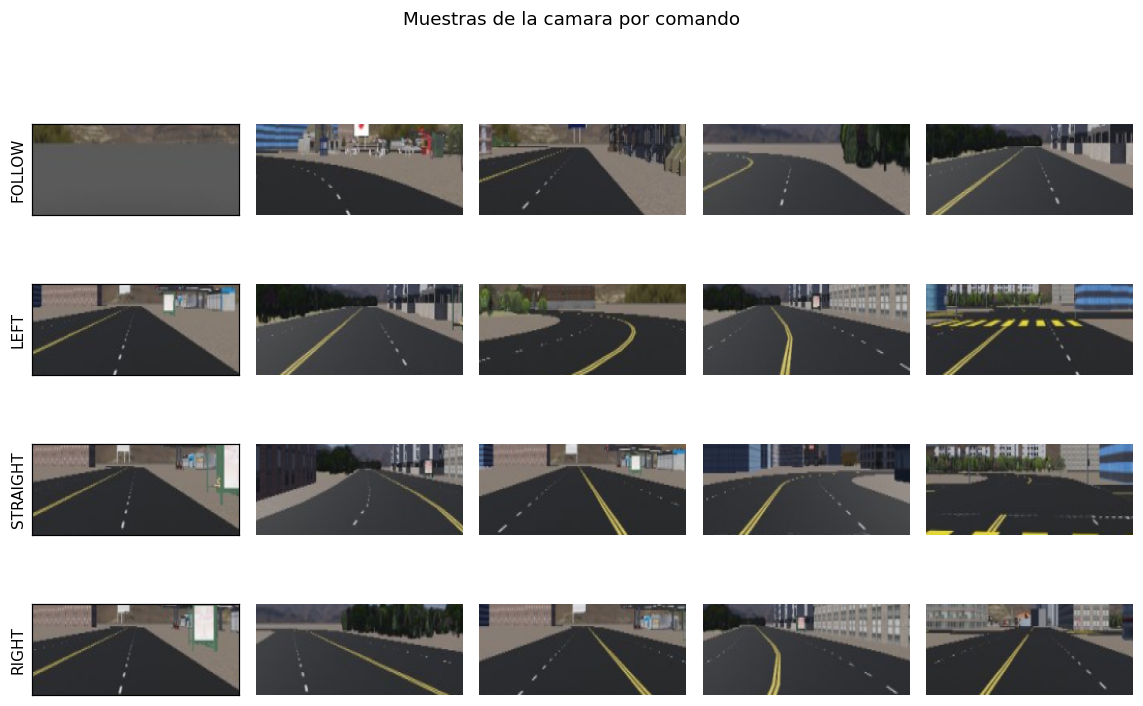

In [7]:
def mostrar_muestras(X, C, n=5):
    cmds = [i for i in range(cil.NUM_COMMANDS) if np.any(C == i)]
    fig, axes = plt.subplots(len(cmds), n, figsize=(n*2.1, len(cmds)*1.7))
    axes = np.atleast_2d(axes)
    for r, ci in enumerate(cmds):
        idx = np.where(C == ci)[0]
        sel = idx[np.linspace(0, len(idx)-1, n).astype(int)]
        for c in range(n):
            ax = axes[r][c]; ax.axis('off')
            ax.imshow(X[sel[c]])
            if c == 0:
                ax.set_ylabel(CMD_NAMES[ci]); ax.axis('on')
                ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle('Muestras de la camara por comando', y=1.01)
    plt.tight_layout(); plt.show()

mostrar_muestras(X, C)

## 5. Preprocesamiento

El modelo no recibe la imagen completa de la camara: se **recorta la franja de la carretera** (se quita el cielo y el cofre), se convierte a RGB y se redimensiona a la entrada estilo Codevilla (88x200). Este mismo preprocesamiento se aplica en el controlador de Webots para que la inferencia coincida con el entrenamiento.

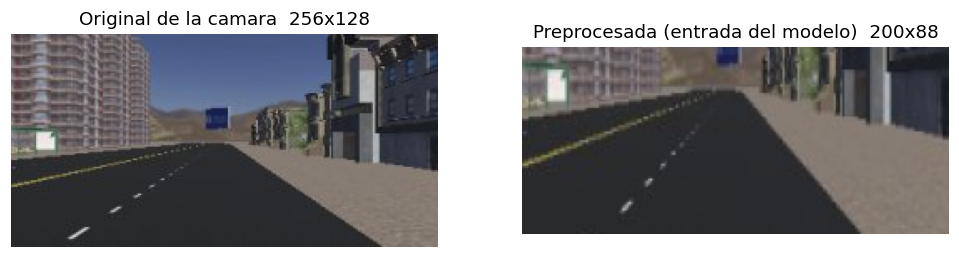

In [8]:
raw_path = sorted(glob.glob(os.path.join(DATA_DIR, 'IMG', '*.*')))[0]
raw_bgr = cv2.imread(raw_path)
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
proc = cil.preprocess(raw_bgr)  # recorte + RGB + resize + /255

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].imshow(raw_rgb); ax[0].set_title(f'Original de la camara  {raw_rgb.shape[1]}x{raw_rgb.shape[0]}')
ax[1].imshow(proc); ax[1].set_title(f'Preprocesada (entrada del modelo)  {cil.IMG_W}x{cil.IMG_H}')
for a in ax: a.axis('off')
plt.show()

## 6. Data augmentation

En Behavioral Cloning el augmentation mas importante es el **flip horizontal**: al voltear la imagen se **niega el angulo** y se **intercambia el comando LEFT<->RIGHT** (FOLLOW y STRAIGHT no cambian). Esto **duplica** el dataset y lo **balancea** entre giros. Se agrega ademas **jitter de brillo** para generalizar entre el Mundo #1 y el #2.

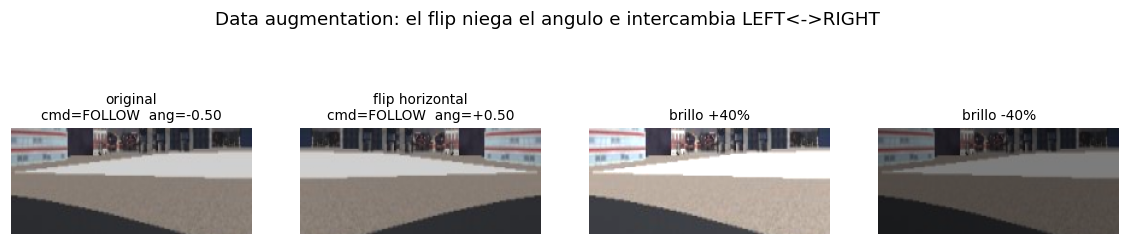

In [9]:
# Elegimos una muestra con angulo marcado para que el efecto del flip se note
cand = np.where(np.abs(y) > 0.05)[0]
i = int(cand[0]) if len(cand) else 0
img, ang, cmd = X[i], float(y[i]), int(C[i])
flip = img[:, ::-1, :]; ang_f = -ang; cmd_f = cil.CMD_FLIP[cmd]
bright = np.clip(img * 1.4, 0, 1); dark = np.clip(img * 0.6, 0, 1)

vistas = [
    (img,    f'original\ncmd={CMD_NAMES[cmd]}  ang={ang:+.2f}'),
    (flip,   f'flip horizontal\ncmd={CMD_NAMES[cmd_f]}  ang={ang_f:+.2f}'),
    (bright, 'brillo +40%'),
    (dark,   'brillo -40%'),
]
fig, ax = plt.subplots(1, 4, figsize=(13, 2.8))
for a, (im, t) in zip(ax, vistas):
    a.imshow(im); a.set_title(t, fontsize=9); a.axis('off')
plt.suptitle('Data augmentation: el flip niega el angulo e intercambia LEFT<->RIGHT', y=1.05)
plt.show()

### 6.1 Rebalanceo de comandos (recomendado)

Como la conduccion suele producir **muchos** FOLLOW y **pocos** giros, primero
rebalanceamos: se submuestrea FOLLOW y se sobremuestrean LEFT/STRAIGHT/RIGHT para
que el modelo no se sesgue a ir siempre recto. `follow_ratio` controla cuanto FOLLOW se conserva respecto a la clase de giro mas numerosa.

[BALANCE] 13296 -> 16294 muestras (FOLLOW<= 5431, cada giro -> 3621)
[BALANCE] (balanceado) {'FOLLOW': 5431, 'LEFT': 3621, 'STRAIGHT': 3621, 'RIGHT': 3621}


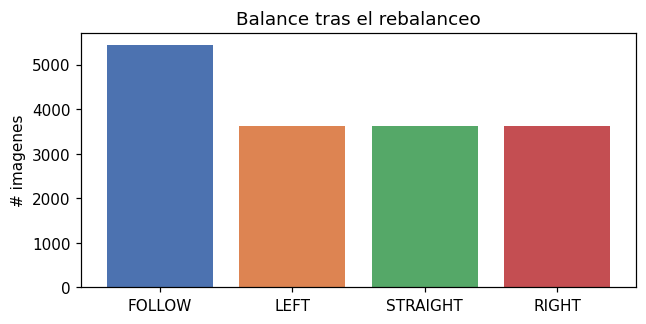

In [10]:
Xb, Cb, yb = cil.balance_dataset(X, C, y, follow_ratio=1.5)
v = [int(np.sum(Cb == k)) for k in range(cil.NUM_COMMANDS)]
plt.figure(figsize=(6.5, 3))
plt.bar(names, v, color=COLORS); plt.title('Balance tras el rebalanceo'); plt.ylabel('# imagenes')
plt.show()

### 6.2 Aplicar el augmentation al dataset balanceado

[AUGMENT] Dataset: 16294 -> 32588 imagenes
[BALANCE] (aumentado) {'FOLLOW': 10862, 'LEFT': 7242, 'STRAIGHT': 7242, 'RIGHT': 7242}


Dataset: 13296 -> 32588 imagenes tras augmentation


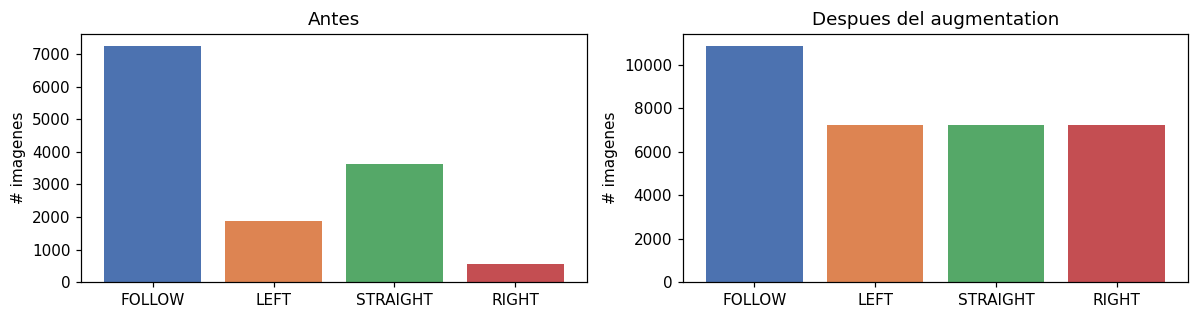

In [11]:
Xa, Ca, ya = cil.augment(Xb, Cb, yb, brightness_copies=0)
print(f'Dataset: {len(X)} -> {len(Xa)} imagenes tras augmentation')
if len(Xa) <= 10000:
    print('NOTA: el dataset final deberia superar 10 mil imagenes. '
          'Sube brightness_copies o recolecta mas datos.')

# Balance antes vs despues
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for a, (Cc, t) in zip(ax, [(C, 'Antes'), (Ca, 'Despues del augmentation')]):
    v = [int(np.sum(Cc == k)) for k in range(cil.NUM_COMMANDS)]
    a.bar(names, v, color=COLORS)
    a.set_title(t); a.set_ylabel('# imagenes')
plt.tight_layout(); plt.show()

## 7. Arquitectura del modelo CIL ramificado

Combina la idea **ramificada por comando de Codevilla et al. (2018)** con un **backbone convolucional ligero estilo Bojarski et al. (2016)** — el modelo que recomienda el enunciado. Cinco capas conv (24/36/48/64/64) con reduccion por stride + Flatten + Dense(128) extraen las caracteristicas; luego **una rama por comando** (FOLLOW/LEFT/STRAIGHT/RIGHT) predice el angulo. El comando one-hot **selecciona** que rama produce la salida (mascara), de modo que el modelo tiene una sola salida y se entrena con MSE. El backbone ligero (~2.4M parametros) entrena en CPU en minutos.

In [12]:
model = cil.construir_cil()
model.summary()

Model: "cil_branched"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 88, 200,   │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 44, 100,   │      1,824 │ image[0][0]       │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 22, 50,    │     21,636 │ conv2d[0][0]      │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 11, 25,    │     43,248 │ conv2d_1[0][0]    │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 11, 25,    │     27,712 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 11, 25,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 11, 25,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 17600)     │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  2,252,928 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_follow_fc    │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_left_fc      │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_straight_fc  │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_right_fc     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ branch_follow_fc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ branch_left_fc[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ branch_straight_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ branch_right_fc[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_follow_out   │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                 

 Total params: 2,417,560 (9.22 MB)

 Trainable params: 2,417,560 (9.22 MB)

 Non-trainable params: 0 (0.00 B)

### 7.1 Diagrama del modelo
Visualizamos las dos entradas (imagen + comando), el backbone, las cuatro ramas y la seleccion por mascara.

In [ ]:
try:
    from tensorflow.keras.utils import plot_model
    from IPython.display import Image, display
    plot_model(model, to_file='cil_model.png', show_shapes=True,
               show_layer_names=False, dpi=64, rankdir='TB')
    display(Image('cil_model.png'))
except Exception as e:
    print('plot_model no disponible (instala pydot/graphviz):', e)

Diagrama del modelo: se genera con plot_model en Google Colab (que incluye graphviz).
El detalle de capas esta en la seccion anterior (model.summary()).


## 8. Entrenamiento

Entrenamos con **Adam** (lr=1e-3), perdida **MSE** sobre el angulo y metrica **MAE**. Usamos `EarlyStopping` (se detiene si la validacion deja de mejorar y restaura los mejores pesos) y `ReduceLROnPlateau` (baja el learning rate cuando se estanca).

In [14]:
history, val_data = cil.entrenar(model, Xa, Ca, ya, epochs=12, batch_size=128)

Epoch 1/12


204/204 - 24s - 119ms/step - loss: 0.0199 - mae: 0.0829 - val_loss: 0.0155 - val_mae: 0.0696 - learning_rate: 0.0010


Epoch 2/12


204/204 - 22s - 109ms/step - loss: 0.0138 - mae: 0.0622 - val_loss: 0.0113 - val_mae: 0.0520 - learning_rate: 0.0010


Epoch 3/12


...

204/204 - 22s - 110ms/step - loss: 0.0048 - mae: 0.0335 - val_loss: 0.0062 - val_mae: 0.0325 - learning_rate: 0.0010


Epoch 11/12


204/204 - 22s - 110ms/step - loss: 0.0042 - mae: 0.0311 - val_loss: 0.0056 - val_mae: 0.0303 - learning_rate: 0.0010


Epoch 12/12


204/204 - 23s - 111ms/step - loss: 0.0040 - mae: 0.0302 - val_loss: 0.0053 - val_mae: 0.0295 - learning_rate: 0.0010


## 9. Curvas de entrenamiento
Vigilamos sobreajuste: si la curva de validacion se separa mucho de la de entrenamiento, el modelo memoriza en vez de generalizar.

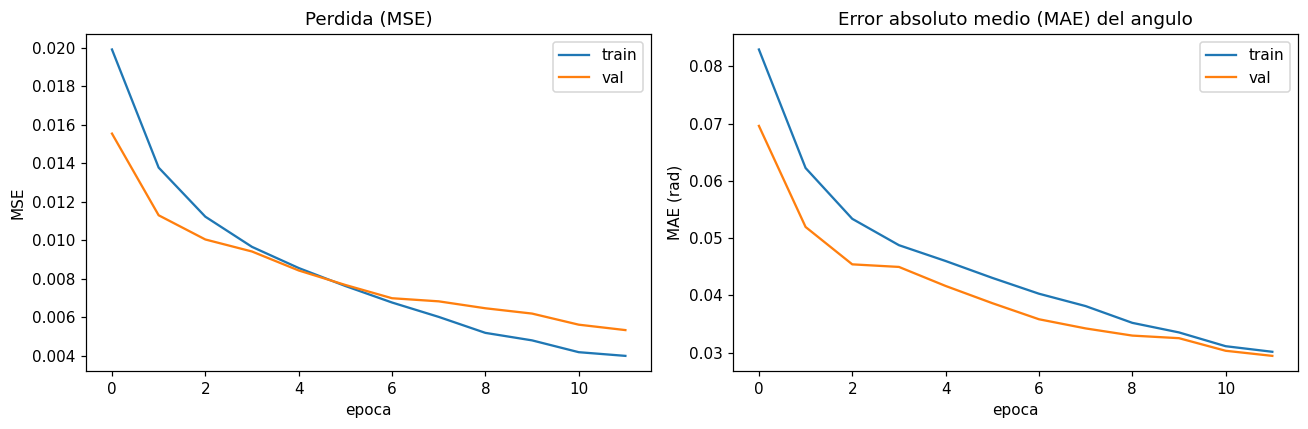

Mejor val_MAE: 0.0295 rad


In [15]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
ax[0].set_title('Perdida (MSE)'); ax[0].set_xlabel('epoca'); ax[0].set_ylabel('MSE'); ax[0].legend()
ax[1].plot(h['mae'], label='train'); ax[1].plot(h['val_mae'], label='val')
ax[1].set_title('Error absoluto medio (MAE) del angulo'); ax[1].set_xlabel('epoca')
ax[1].set_ylabel('MAE (rad)'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Mejor val_MAE: {min(h['val_mae']):.4f} rad")

## 10. Evaluacion

Medimos el desempeno en el conjunto de validacion desde varios angulos.

### 10.1 MAE por comando
El error promedio del angulo, desglosado por comando. Util para detectar si alguna rama (p.ej. LEFT) esta peor entrenada por falta de datos.

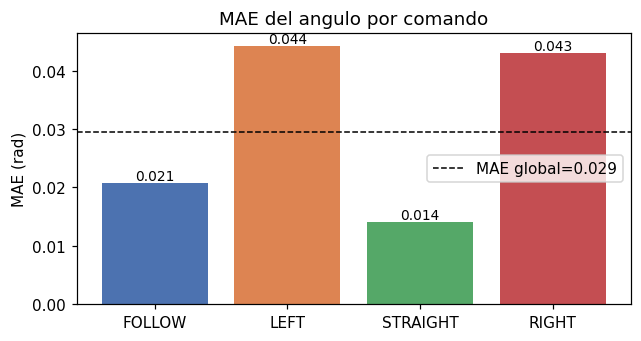

In [16]:
Xv, Cv_oh, yv, Cv = val_data
pred = model.predict([Xv, Cv_oh], verbose=0).ravel()

mae_global = float(np.mean(np.abs(pred - yv)))
maes = []
for i in range(cil.NUM_COMMANDS):
    m = Cv == i
    maes.append(float(np.mean(np.abs(pred[m] - yv[m]))) if np.any(m) else 0.0)

plt.figure(figsize=(6.5, 3.2))
bars = plt.bar(names, maes, color=COLORS)
for b, v in zip(bars, maes):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.axhline(mae_global, color='k', ls='--', lw=1, label=f'MAE global={mae_global:.3f}')
plt.title('MAE del angulo por comando'); plt.ylabel('MAE (rad)'); plt.legend()
plt.show()

### 10.2 Prediccion vs valor real
Si el modelo es bueno, los puntos caen sobre la diagonal (prediccion = real).

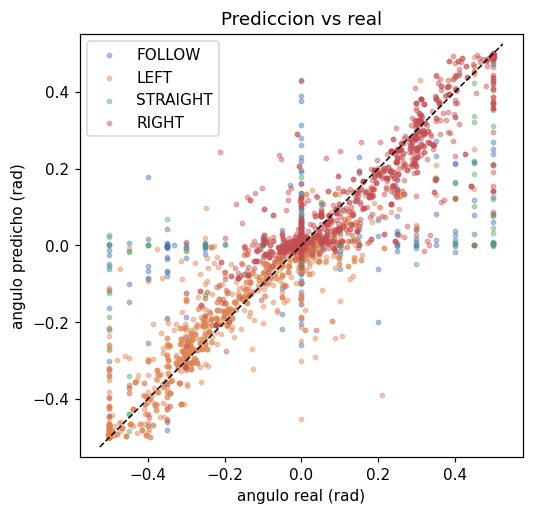

In [17]:
plt.figure(figsize=(5.2, 5))
for i in range(cil.NUM_COMMANDS):
    m = Cv == i
    if np.any(m):
        plt.scatter(yv[m], pred[m], s=8, alpha=0.4, color=COLORS[i], label=CMD_NAMES[i])
lim = cil.MAX_ANGLE * 1.05
plt.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
plt.xlabel('angulo real (rad)'); plt.ylabel('angulo predicho (rad)')
plt.title('Prediccion vs real'); plt.legend(); plt.axis('equal')
plt.show()

### 10.3 Distribucion del error

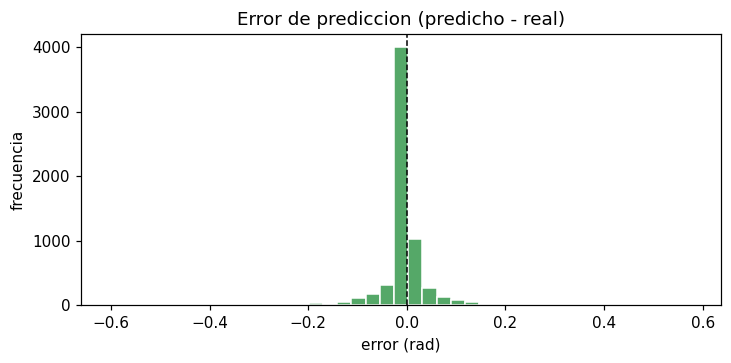

Error medio: -0.0005 rad  |  desviacion: 0.0730 rad


In [18]:
err = pred - yv
plt.figure(figsize=(7.5, 3.2))
plt.hist(err, bins=41, color='#55A868', edgecolor='white')
plt.axvline(0, color='k', ls='--', lw=1)
plt.title('Error de prediccion (predicho - real)')
plt.xlabel('error (rad)'); plt.ylabel('frecuencia')
plt.show()
print(f'Error medio: {err.mean():+.4f} rad  |  desviacion: {err.std():.4f} rad')

### 10.4 Predicciones visualizadas
Mostramos imagenes de validacion con su angulo real y el predicho, y una barra que indica la direccion del volante (izquierda/derecha).

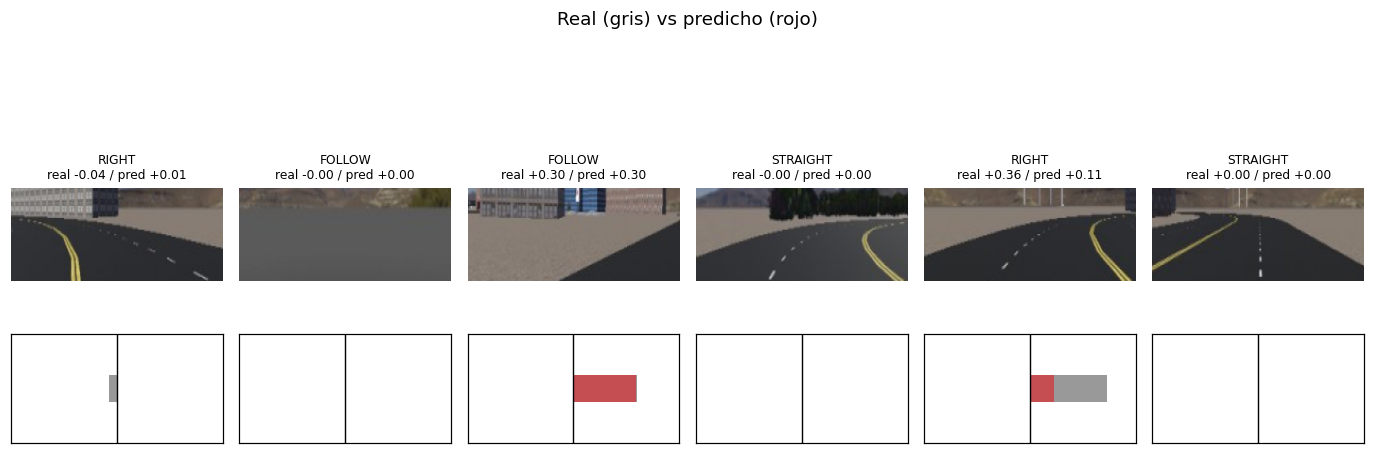

In [19]:
def barra_volante(ax, ang, color):
    # dibuja una barra horizontal centrada que representa el angulo del volante
    ax.barh([0], [ang], color=color, height=0.5)
    ax.set_xlim(-cil.MAX_ANGLE, cil.MAX_ANGLE); ax.set_ylim(-1, 1)
    ax.axvline(0, color='k', lw=0.8); ax.set_yticks([]); ax.set_xticks([])

idx = np.random.default_rng(0).choice(len(Xv), size=min(6, len(Xv)), replace=False)
fig, axes = plt.subplots(2, len(idx), figsize=(len(idx)*2.1, 4),
                         gridspec_kw={'height_ratios':[3,1]})
for c, k in enumerate(idx):
    axes[0][c].imshow(Xv[k]); axes[0][c].axis('off')
    axes[0][c].set_title(f'{CMD_NAMES[int(Cv[k])]}\nreal {yv[k]:+.2f} / pred {pred[k]:+.2f}', fontsize=8)
    barra_volante(axes[1][c], yv[k], '#999999')
    barra_volante(axes[1][c], pred[k], '#C44E52')
plt.suptitle('Real (gris) vs predicho (rojo)', y=1.02)
plt.tight_layout(); plt.show()

## 11. Exportacion a TensorFlow Lite

Guardamos el modelo en `.keras` (re-entrenamiento) y `.tflite` (lo que carga el controlador de Webots), verificando que ambos produzcan el mismo angulo (paridad).

In [20]:
keras_path, tflite_path = cil.exportar(model, val_data)
print('Listo:', tflite_path)

# Descargar el .tflite para copiarlo al controlador del Mundo #2
try:
    from google.colab import files
    files.download(tflite_path)
except Exception:
    pass

[EXPORT] Modelo Keras guardado en /Users/oscarramirezanaya/Documents/proyectos/maestria/navegacion_autonoma_final/cil_training/model/cil_model.keras


INFO:tensorflow:Assets written to: /var/folders/qj/6h1gvmh96z1d3zqlfjrwh3000000gn/T/tmpclzezpp3/assets


INFO:tensorflow:Assets written to: /var/folders/qj/6h1gvmh96z1d3zqlfjrwh3000000gn/T/tmpclzezpp3/assets


Saved artifact at '/var/folders/qj/6h1gvmh96z1d3zqlfjrwh3000000gn/T/tmpclzezpp3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 88, 200, 3), dtype=tf.float32, name='image'), TensorSpec(shape=(None, 4), dtype=tf.float32, name='command')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  12956867024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957577488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957579024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957577104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957577296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957578832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957579408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957574800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957579600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12957579216: Te

[EXPORT] Modelo TFLite guardado en /Users/oscarramirezanaya/Documents/proyectos/maestria/navegacion_autonoma_final/cil_training/model/cil_model.tflite (2381 KB)
[EXPORT] Paridad Keras vs TFLite (20 muestras): diferencia maxima 0.002435 rad
Listo: /Users/oscarramirezanaya/Documents/proyectos/maestria/navegacion_autonoma_final/cil_training/model/cil_model.tflite


/Users/oscarramirezanaya/Documents/proyectos/env/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 12. Integracion en Webots (Mundo #2)

1. Copia `cil_model.tflite` a `controllers/cil_autonomous/model/`.
2. Abre `worlds/city_traffic_2025_02.wbt` (el controlador `cil_autonomous` ya esta asignado).
3. Durante la simulacion, da el comando de navegacion por teclado (`1`=FOLLOW, `2`=LEFT, `3`=STRAIGHT, `4`=RIGHT). El modelo predice el angulo y las capas de seguridad (peaton, radar, evasion) tienen prioridad sobre el modelo.

**Referencias:** Codevilla et al. (2018), arXiv:1710.02410 · Bojarski et al. (2016), arXiv:1604.07316.